Found 171 folders in the dataset
Processed 3961 images
Training set: 3168 images
Validation set: 793 images
Annotations saved to annotations

Visualizing examples of converted bounding boxes...


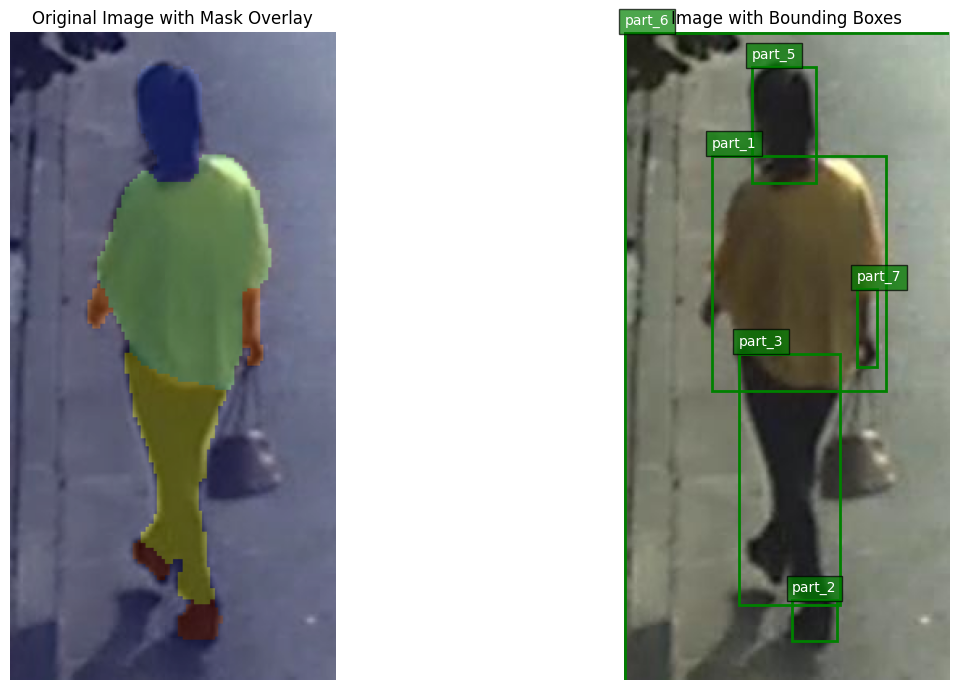

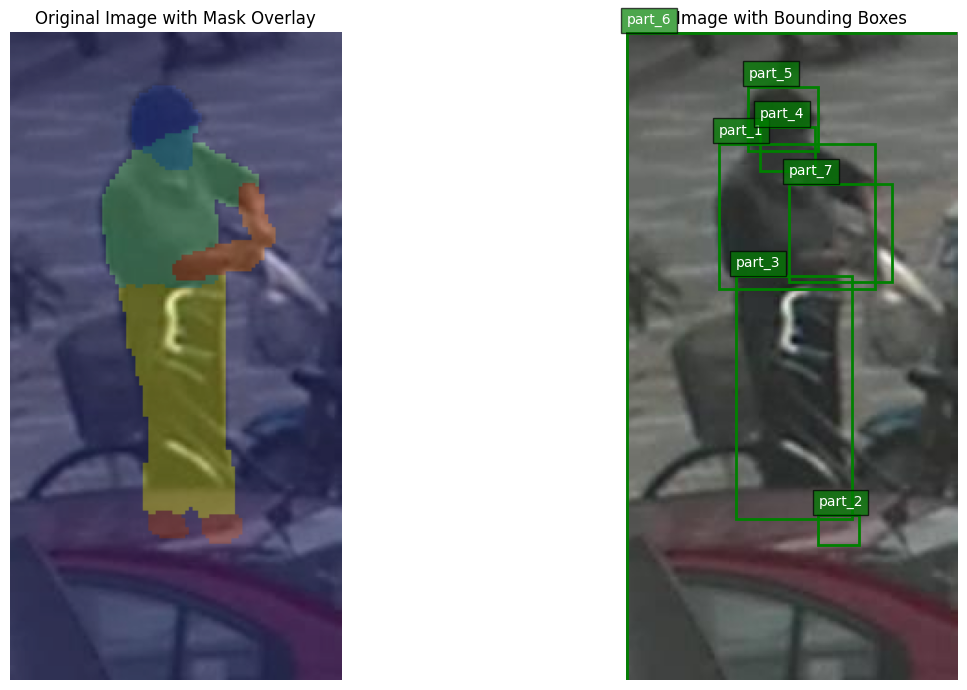

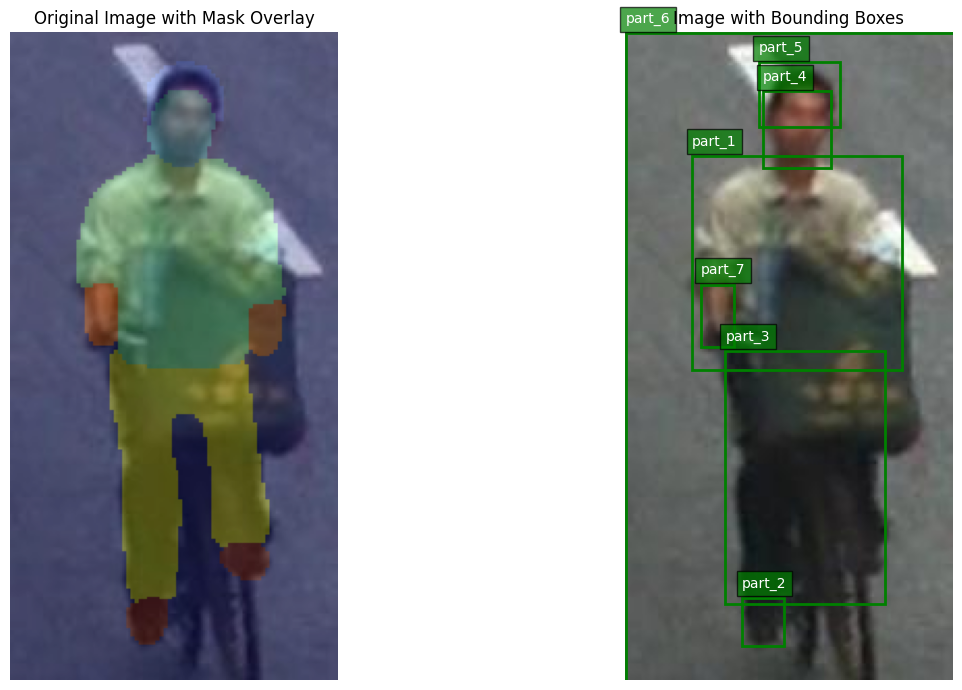


Visualizing part distribution...


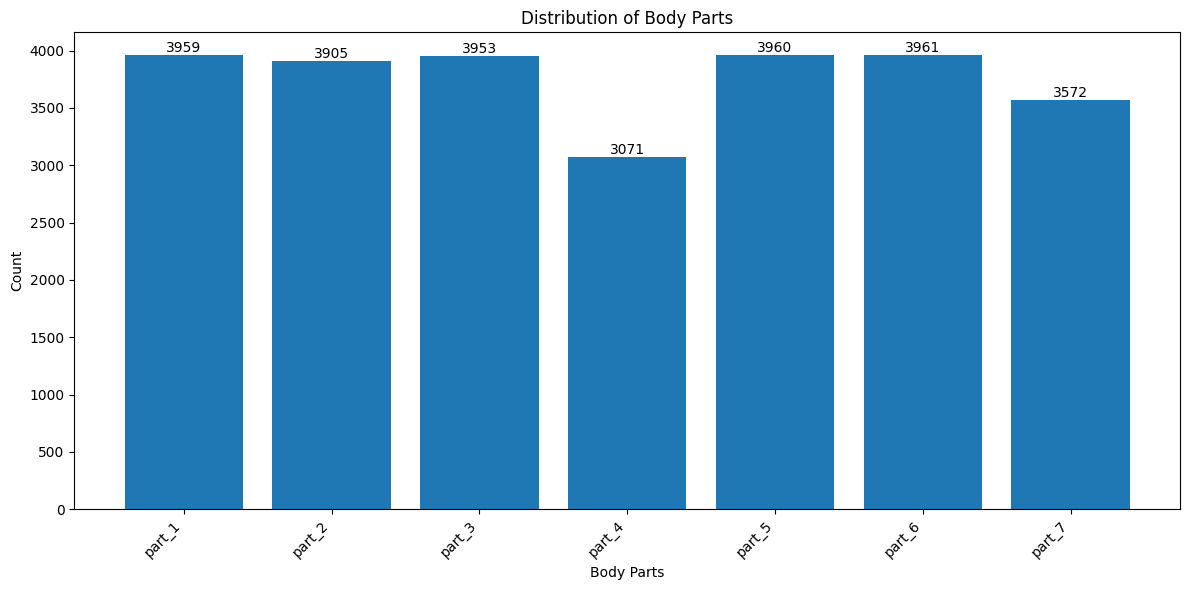

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import json
from collections import defaultdict
import glob
import pandas as pd
class HumanPartsDatasetProcessor:
    def __init__(self, data_dir):
        """
        Initialize the processor with the dataset directory
        
        Args:
            data_dir: Path to the main dataset directory
        """
        self.data_dir = data_dir
        self.part_colors = {}  # Will store unique colors and their part labels
        self.annotations = []
        self.part_distribution = defaultdict(int)
    
    def scan_dataset(self):
        """Scan the dataset structure and return folder statistics"""
        folders = [f for f in os.listdir(self.data_dir) if os.path.isdir(os.path.join(self.data_dir, f))]
        
        folder_stats = {}
        for folder in folders:
            folder_path = os.path.join(self.data_dir, folder)
            images = [f for f in os.listdir(folder_path) if f.endswith('.jpg') and not f.endswith('_m.jpg')]
            masks = [f for f in os.listdir(folder_path) if f.endswith('_m.png')]
            
            folder_stats[folder] = {
                'image_count': len(images),
                'mask_count': len(masks),
                'sample_images': images[:3] if len(images) >= 3 else images
            }
        
        return folder_stats
    
    def extract_part_colors(self, sample_masks_paths, manual_mapping=None):
        """
        Extract unique colors from mask images and assign part labels
        
        Args:
            sample_masks_paths: List of paths to sample mask images
            manual_mapping: Optional dictionary mapping RGB values to part names
        """
        if manual_mapping:
            self.part_colors = manual_mapping
            return
            
        # If no manual mapping provided, we'll create a numeric mapping
        unique_colors = set()
        
        for mask_path in sample_masks_paths:
            # Get the corresponding image path
            image_path = mask_path.replace('_m.png', '.jpg')
            if not os.path.exists(image_path):
                continue
                
            # Read original image to get dimensions
            orig_img = cv2.imread(image_path)
            orig_h, orig_w = orig_img.shape[:2]
            
            # Read and resize mask to match original image dimensions
            mask = cv2.imread(mask_path)
            mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
            mask = cv2.resize(mask, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)
            
            # Extract unique colors
            reshaped_mask = mask.reshape(-1, 3)
            for color in np.unique(reshaped_mask, axis=0):
                color_tuple = tuple(color)
                if not np.all(color == 0):  # Ignore background (if black)
                    unique_colors.add(color_tuple)
        
        # Assign labels to colors
        for i, color in enumerate(unique_colors):
            self.part_colors[color] = f"part_{i+1}"
    
    def mask_to_bboxes(self, image_path, mask_path):
        """
        Convert segmentation mask to bounding boxes
        
        Args:
            image_path: Path to the original image
            mask_path: Path to the corresponding mask image
            
        Returns:
            Dictionary containing bounding boxes for each part
        """
        # Read the original image
        image = cv2.imread(image_path)
        orig_h, orig_w = image.shape[:2]
        
        # Read the mask and ensure it's the same size as the original image
        mask = cv2.imread(mask_path)
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
        
        # Resize mask to match original image dimensions
        if mask.shape[:2] != (orig_h, orig_w):
            mask = cv2.resize(mask, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)
        
        bboxes = {}
        
        # Process each part color
        for color, part_name in self.part_colors.items():
            # Create binary mask for this color
            binary_mask = np.all(mask == color, axis=2).astype(np.uint8)
            
            # Skip if part not present
            if np.sum(binary_mask) == 0:
                continue
                
            # Find contours
            contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            
            if contours:
                # Find the largest contour (in case of multiple disconnected regions)
                largest_contour = max(contours, key=cv2.contourArea)
                x, y, width, height = cv2.boundingRect(largest_contour)
                
                # Store bbox [x1, y1, x2, y2] format
                bboxes[part_name] = [int(x), int(y), int(x + width), int(y + height)]
                self.part_distribution[part_name] += 1
        
        return bboxes
    
    def process_dataset(self):
        """
        Process the entire dataset and create annotations
        
        Returns:
            List of annotation dictionaries
        """
        # First define part colors using some sample masks
        sample_masks = []
        for folder in os.listdir(self.data_dir):
            folder_path = os.path.join(self.data_dir, folder)
            if os.path.isdir(folder_path):
                mask_files = glob.glob(os.path.join(folder_path, "*_m.png"))
                if mask_files:
                    sample_masks.extend(mask_files[:2])  # Take first 2 masks from each folder
                    if len(sample_masks) >= 10:  # Limit samples
                        break
        
        # Option 1: Extract colors automatically
        self.extract_part_colors(sample_masks)
        
        # Process all image-mask pairs
        for folder in os.listdir(self.data_dir):
            folder_path = os.path.join(self.data_dir, folder)
            if os.path.isdir(folder_path):
                # Find all image files that have a corresponding mask
                image_files = [f for f in os.listdir(folder_path) if f.endswith('.jpg') and not f.endswith('_m.jpg')]
                
                for img_file in image_files:
                    # Find corresponding mask file
                    mask_file = img_file.replace('.jpg', '_m.png')
                    mask_path = os.path.join(folder_path, mask_file)
                    
                    # Skip if mask doesn't exist
                    if not os.path.exists(mask_path):
                        continue
                    
                    img_path = os.path.join(folder_path, img_file)
                    
                    # Get image dimensions
                    img = cv2.imread(img_path)
                    height, width = img.shape[:2]
                    
                    # Convert mask to bounding boxes
                    bboxes = self.mask_to_bboxes(img_path, mask_path)
                    
                    # Create annotation entry
                    annotation = {
                        'image_id': img_file,
                        'file_path': img_path,
                        'width': width,
                        'height': height,
                        'bboxes': bboxes
                    }
                    
                    self.annotations.append(annotation)
        
        return self.annotations
    
    def split_dataset(self, test_size=0.2, random_state=42):
        """
        Split annotations into training and validation sets
        
        Args:
            test_size: Proportion of the dataset to include in the validation split
            random_state: Random seed for reproducibility
            
        Returns:
            train_annotations, val_annotations
        """
        if not self.annotations:
            raise ValueError("Process the dataset first using process_dataset()")
        
        train_anns, val_anns = train_test_split(self.annotations, test_size=test_size, random_state=random_state)
        
        print(f"Training set: {len(train_anns)} images")
        print(f"Validation set: {len(val_anns)} images")
        
        return train_anns, val_anns
    
    def visualize_bboxes(self, sample_count=5):
        """
        Visualize some sample images with bounding boxes overlaid
        
        Args:
            sample_count: Number of samples to visualize
        """
        if not self.annotations:
            raise ValueError("Process the dataset first using process_dataset()")
        
        samples = np.random.choice(self.annotations, min(sample_count, len(self.annotations)), replace=False)
        
        for i, sample in enumerate(samples):
            # Load image
            img = cv2.imread(sample['file_path'])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # Load mask for visualization (original mask)
            mask_path = sample['file_path'].replace('.jpg', '_m.png')
            if os.path.exists(mask_path):
                mask = cv2.imread(mask_path)
                mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
                
                # Resize mask to match image dimensions
                mask = cv2.resize(mask, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
                
                # Create a figure with two subplots
                fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
                
                # Display original image with mask overlay (semi-transparent)
                ax1.imshow(img)
                mask_overlay = mask.copy()
                # Make black background transparent
                mask_alpha = np.all(mask == [0, 0, 0], axis=2)
                mask_overlay = np.dstack([mask_overlay, np.where(mask_alpha, 0, 128)])  # Alpha channel
                ax1.imshow(mask_overlay, alpha=0.5)
                ax1.set_title("Original Image with Mask Overlay")
                ax1.axis('off')
                
                # Display image with bounding boxes
                ax2.imshow(img)
                for part_name, bbox in sample['bboxes'].items():
                    x1, y1, x2, y2 = bbox
                    rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='g', facecolor='none')
                    ax2.add_patch(rect)
                    ax2.text(x1, y1-5, part_name, fontsize=10, color='white', 
                             bbox=dict(facecolor='green', alpha=0.7))
                ax2.set_title("Image with Bounding Boxes")
                ax2.axis('off')
                
                plt.tight_layout()
                plt.show()
            else:
                # If mask doesn't exist, just show the image with bounding boxes
                plt.figure(figsize=(10, 8))
                plt.imshow(img)
                
                for part_name, bbox in sample['bboxes'].items():
                    x1, y1, x2, y2 = bbox
                    rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='g', facecolor='none')
                    plt.gca().add_patch(rect)
                    plt.text(x1, y1-5, part_name, fontsize=10, color='white', 
                            bbox=dict(facecolor='green', alpha=0.7))
                
                plt.title(f"Sample {i+1}: {os.path.basename(sample['file_path'])}")
                plt.axis('off')
                plt.show()
    
    def visualize_part_distribution(self):
        """Visualize the distribution of body parts in the dataset"""
        if not self.part_distribution:
            raise ValueError("Process the dataset first using process_dataset()")
        
        parts = list(self.part_distribution.keys())
        counts = list(self.part_distribution.values())
        
        plt.figure(figsize=(12, 6))
        bars = plt.bar(parts, counts)
        
        # Add count labels on top of bars
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                    f'{height}', ha='center', va='bottom')
        
        plt.xlabel('Body Parts')
        plt.ylabel('Count')
        plt.title('Distribution of Body Parts')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    
    def save_annotations(self, train_anns, val_anns, output_dir):
        """
        Save annotations to JSON files
        
        Args:
            train_anns: Training annotations
            val_anns: Validation annotations
            output_dir: Directory to save the annotation files
        """
        os.makedirs(output_dir, exist_ok=True)
        
        with open(os.path.join(output_dir, 'train_annotations.json'), 'w') as f:
            json.dump(train_anns, f, indent=2)
        
        with open(os.path.join(output_dir, 'val_annotations.json'), 'w') as f:
            json.dump(val_anns, f, indent=2)
        
        # Save part color mapping
        with open(os.path.join(output_dir, 'part_colors.json'), 'w') as f:
            # Convert tuple keys to strings for JSON serialization
            color_map = {str(color): part for color, part in self.part_colors.items()}
            json.dump(color_map, f, indent=2)
            
        # Save part distribution statistics
        with open(os.path.join(output_dir, 'part_distribution.json'), 'w') as f:
            json.dump(self.part_distribution, f, indent=2)
        
        print(f"Annotations saved to {output_dir}")

    def analyze_bbox_properties(self):
        """
        Analyze the scale, aspect ratio, and positioning of bounding box annotations
        
        Returns:
            Dictionary containing statistics for each part
        """
        if not self.annotations:
            raise ValueError("Process the dataset first using process_dataset()")
        
        # Initialize dictionaries to store statistics
        stats = defaultdict(lambda: {
            'widths': [],
            'heights': [],
            'areas': [],
            'aspect_ratios': [],
            'rel_x_positions': [],  # Relative x position (center of bbox / image width)
            'rel_y_positions': [],  # Relative y position (center of bbox / image height)
            'rel_areas': []         # Relative area (bbox area / image area)
        })
        
        # Collect data
        for annotation in self.annotations:
            img_width = annotation['width']
            img_height = annotation['height']
            img_area = img_width * img_height
            
            for part_name, bbox in annotation['bboxes'].items():
                x1, y1, x2, y2 = bbox
                width = x2 - x1
                height = y2 - y1
                area = width * height
                aspect_ratio = width / height if height > 0 else 0
                
                # Center coordinates
                center_x = (x1 + x2) / 2
                center_y = (y1 + y2) / 2
                
                # Relative positions (normalized by image dimensions)
                rel_x = center_x / img_width
                rel_y = center_y / img_height
                rel_area = area / img_area
                
                # Store values
                stats[part_name]['widths'].append(width)
                stats[part_name]['heights'].append(height)
                stats[part_name]['areas'].append(area)
                stats[part_name]['aspect_ratios'].append(aspect_ratio)
                stats[part_name]['rel_x_positions'].append(rel_x)
                stats[part_name]['rel_y_positions'].append(rel_y)
                stats[part_name]['rel_areas'].append(rel_area)
        
        # Calculate statistics for each part
        results = {}
        for part_name, data in stats.items():
            results[part_name] = {
                'count': len(data['widths']),
                'width': {
                    'min': min(data['widths']),
                    'max': max(data['widths']),
                    'mean': np.mean(data['widths']),
                    'std': np.std(data['widths'])
                },
                'height': {
                    'min': min(data['heights']),
                    'max': max(data['heights']),
                    'mean': np.mean(data['heights']),
                    'std': np.std(data['heights'])
                },
                'area': {
                    'min': min(data['areas']),
                    'max': max(data['areas']),
                    'mean': np.mean(data['areas']),
                    'std': np.std(data['areas'])
                },
                'aspect_ratio': {
                    'min': min(data['aspect_ratios']),
                    'max': max(data['aspect_ratios']),
                    'mean': np.mean(data['aspect_ratios']),
                    'std': np.std(data['aspect_ratios'])
                },
                'rel_x_position': {
                    'min': min(data['rel_x_positions']),
                    'max': max(data['rel_x_positions']),
                    'mean': np.mean(data['rel_x_positions']),
                    'std': np.std(data['rel_x_positions'])
                },
                'rel_y_position': {
                    'min': min(data['rel_y_positions']),
                    'max': max(data['rel_y_positions']),
                    'mean': np.mean(data['rel_y_positions']),
                    'std': np.std(data['rel_y_positions'])
                },
                'rel_area': {
                    'min': min(data['rel_areas']),
                    'max': max(data['rel_areas']),
                    'mean': np.mean(data['rel_areas']),
                    'std': np.std(data['rel_areas'])
                }
            }
            # Store raw data for visualization
            results[part_name]['raw_data'] = data
        return results
    def visualize_scale_variations(self, stats):
        """
        Visualize variations in scale (area) for each part
        
        Args:
            stats: Statistics dictionary from analyze_bbox_properties
        """
        plt.figure(figsize=(12, 6))
        
        parts = list(stats.keys())
        
        # Create boxplot for relative areas
        rel_areas_data = [stats[part]['raw_data']['rel_areas'] for part in parts]
        
        plt.boxplot(rel_areas_data, labels=parts)
        plt.title('Variation in Relative Areas of Body Parts')
        plt.ylabel('Relative Area (bbox area / image area)')
        plt.xlabel('Body Parts')
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
        
        # Create histogram for each part
        num_parts = len(parts)
        cols = min(3, num_parts)
        rows = (num_parts + cols - 1) // cols
        
        fig, axes = plt.subplots(rows, cols, figsize=(15, 4*rows))
        if rows == 1 and cols == 1:
            axes = np.array([axes])
        axes = axes.flatten()
        
        for i, part in enumerate(parts):
            if i < len(axes):
                data = stats[part]['raw_data']['rel_areas']
                axes[i].hist(data, bins=20, alpha=0.7)
                axes[i].set_title(f'{part} Area Distribution')
                axes[i].set_xlabel('Relative Area')
                axes[i].set_ylabel('Frequency')
                axes[i].grid(axis='y', linestyle='--', alpha=0.5)
        
        # Hide unused subplots
        for i in range(len(parts), len(axes)):
            fig.delaxes(axes[i])
            
        plt.tight_layout()
        plt.show()

    def visualize_aspect_ratio_variations(self, stats):
        """
        Visualize variations in aspect ratio for each part
        
        Args:
            stats: Statistics dictionary from analyze_bbox_properties
        """
        plt.figure(figsize=(12, 6))
        
        parts = list(stats.keys())
        
        # Create boxplot for aspect ratios
        aspect_ratios_data = [stats[part]['raw_data']['aspect_ratios'] for part in parts]
        
        plt.boxplot(aspect_ratios_data, labels=parts)
        plt.title('Variation in Aspect Ratios of Body Parts')
        plt.ylabel('Aspect Ratio (width / height)')
        plt.xlabel('Body Parts')
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
        
        # Create scatterplot of width vs height
        plt.figure(figsize=(12, 8))
        
        for part in parts:
            widths = stats[part]['raw_data']['widths']
            heights = stats[part]['raw_data']['heights']
            plt.scatter(widths, heights, alpha=0.6, label=part)
        
        plt.title('Width vs Height for Different Body Parts')
        plt.xlabel('Width (pixels)')
        plt.ylabel('Height (pixels)')
        plt.grid(linestyle='--', alpha=0.7)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def visualize_positioning(self, stats):
        """
        Visualize the positioning of parts within images
        
        Args:
            stats: Statistics dictionary from analyze_bbox_properties
        """
        parts = list(stats.keys())
        colors = plt.cm.tab10(np.linspace(0, 1, len(parts)))
        
        # Create a scatter plot showing relative positions
        plt.figure(figsize=(10, 10))
        
        for i, part in enumerate(parts):
            rel_x = stats[part]['raw_data']['rel_x_positions']
            rel_y = stats[part]['raw_data']['rel_y_positions']
            plt.scatter(rel_x, rel_y, color=colors[i], alpha=0.6, label=part)
        
        plt.xlim(0, 1)
        plt.ylim(0, 1)
        plt.title('Relative Positions of Body Parts')
        plt.xlabel('Relative X Position')
        plt.ylabel('Relative Y Position')
        plt.grid(linestyle='--', alpha=0.7)
        plt.legend()
        
        # Add a box representing image boundaries
        plt.plot([0, 1, 1, 0, 0], [0, 0, 1, 1, 0], 'k--', alpha=0.5)
        
        plt.tight_layout()
        plt.show()
        
        # Create heatmaps for each part
        num_parts = len(parts)
        cols = min(3, num_parts)
        rows = (num_parts + cols - 1) // cols
        
        fig, axes = plt.subplots(rows, cols, figsize=(15, 4*rows))
        if rows == 1 and cols == 1:
            axes = np.array([axes])
        axes = axes.flatten()
        
        for i, part in enumerate(parts):
            if i < len(axes):
                rel_x = stats[part]['raw_data']['rel_x_positions']
                rel_y = stats[part]['raw_data']['rel_y_positions']
                
                # Create 2D histogram (heatmap)
                heatmap, xedges, yedges = np.histogram2d(
                    rel_x, rel_y, bins=20, range=[[0, 1], [0, 1]]
                )
                
                # Mesh grid for plotting
                x_centers = (xedges[:-1] + xedges[1:]) / 2
                y_centers = (yedges[:-1] + yedges[1:]) / 2
                X, Y = np.meshgrid(x_centers, y_centers)
                
                # Plot heatmap
                im = axes[i].pcolormesh(X, Y, heatmap.T, cmap='hot')
                axes[i].set_title(f'{part} Positioning Heatmap')
                axes[i].set_xlabel('Relative X Position')
                axes[i].set_ylabel('Relative Y Position')
                axes[i].set_aspect('equal')
                fig.colorbar(im, ax=axes[i], label='Frequency')
        
        # Hide unused subplots
        for i in range(len(parts), len(axes)):
            fig.delaxes(axes[i])
            
        plt.tight_layout()
        plt.show()

    def analyze_and_visualize_variations(self):
        """Analyze and visualize variations in scale, aspect ratio, and positioning"""
        if not self.annotations:
            raise ValueError("Process the dataset first using process_dataset()")
        
        # Analyze properties
        stats = self.analyze_bbox_properties()
        
        # Print summary statistics
        print("=== Summary Statistics for Body Parts ===")
        for part, data in stats.items():
            print(f"\n{part} (Count: {data['count']})")
            print(f"  Width: mean={data['width']['mean']:.1f}, std={data['width']['std']:.1f}, range=[{data['width']['min']}-{data['width']['max']}]")
            print(f"  Height: mean={data['height']['mean']:.1f}, std={data['height']['std']:.1f}, range=[{data['height']['min']}-{data['height']['max']}]")
            print(f"  Aspect Ratio: mean={data['aspect_ratio']['mean']:.2f}, std={data['aspect_ratio']['std']:.2f}")
            print(f"  Relative Area: mean={data['rel_area']['mean']:.4f}, std={data['rel_area']['std']:.4f}")
            print(f"  Positioning: X={data['rel_x_position']['mean']:.2f}±{data['rel_x_position']['std']:.2f}, Y={data['rel_y_position']['mean']:.2f}±{data['rel_y_position']['std']:.2f}")
        
        # Visualize variations
        print("\nGenerating visualizations...")
        self.visualize_scale_variations(stats)
        self.visualize_aspect_ratio_variations(stats)
        self.visualize_positioning(stats)
        
        return stats

    def export_analysis_report(self, stats, output_dir):
        """
        Export a detailed analysis report
        
        Args:
            stats: Statistics dictionary from analyze_bbox_properties
            output_dir: Directory to save the report
        """
        os.makedirs(output_dir, exist_ok=True)
        
        # Create a DataFrame for each metric
        metrics = ['width', 'height', 'area', 'aspect_ratio', 'rel_x_position', 'rel_y_position', 'rel_area']
        for metric in metrics:
            data = {
                'part': [],
                'count': [],
                'min': [],
                'max': [],
                'mean': [],
                'std': []
            }
            
            for part, part_stats in stats.items():
                data['part'].append(part)
                data['count'].append(part_stats['count'])
                data['min'].append(part_stats[metric]['min'])
                data['max'].append(part_stats[metric]['max'])
                data['mean'].append(part_stats[metric]['mean'])
                data['std'].append(part_stats[metric]['std'])
            
            df = pd.DataFrame(data)
            df.to_csv(os.path.join(output_dir, f'{metric}_stats.csv'), index=False)
        
        # Save raw data for future analysis
        for part, part_stats in stats.items():
            # Remove raw data before saving to JSON
            clean_stats = {k: v for k, v in part_stats.items() if k != 'raw_data'}
            
            with open(os.path.join(output_dir, f'{part}_stats.json'), 'w') as f:
                json.dump(clean_stats, f, indent=2)
        
        print(f"Analysis report exported to {output_dir}")



# Example usage
# if __name__ == "__main__":
data_dir = "./Datasets/Q3/data"
output_dir = "annotations"
analysis_dir = "analysis_report"

# 2. Create the processor instance
processor = HumanPartsDatasetProcessor(data_dir)

# 3. Scan and print dataset structure
folder_stats = processor.scan_dataset()
print(f"Found {len(folder_stats)} folders in the dataset")

# 4. Process all images and create annotations
annotations = processor.process_dataset()
print(f"Processed {len(annotations)} images")

# 5. Split dataset into training and validation sets
train_anns, val_anns = processor.split_dataset(test_size=0.2)

# 6. Save annotations to files
processor.save_annotations(train_anns, val_anns, output_dir)

# 7. Visualize examples of converted bounding boxes
print("\nVisualizing examples of converted bounding boxes...")
processor.visualize_bboxes(sample_count=3)

# 8. Visualize part distribution
print("\nVisualizing part distribution...")
processor.visualize_part_distribution()




Analyzing variations in scale, aspect ratio, and positioning...
=== Summary Statistics for Body Parts ===

part_1 (Count: 3959)
  Width: mean=102.0, std=40.0, range=[26-319]
  Height: mean=121.8, std=43.7, range=[28-347]
  Aspect Ratio: mean=0.86, std=0.22
  Relative Area: mean=0.1971, std=0.0646
  Positioning: X=0.51±0.05, Y=0.36±0.04

part_2 (Count: 3905)
  Width: mean=37.0, std=18.6, range=[1-197]
  Height: mean=25.4, std=12.3, range=[1-110]
  Aspect Ratio: mean=1.59, std=0.75
  Relative Area: mean=0.0149, std=0.0082
  Positioning: X=0.52±0.17, Y=0.89±0.05

part_3 (Count: 3953)
  Width: mean=83.7, std=38.0, range=[17-322]
  Height: mean=136.6, std=50.4, range=[31-410]
  Aspect Ratio: mean=0.64, std=0.27
  Relative Area: mean=0.1776, std=0.0583
  Positioning: X=0.52±0.06, Y=0.69±0.04

part_4 (Count: 3071)
  Width: mean=31.1, std=13.7, range=[1-130]
  Height: mean=33.4, std=15.9, range=[1-164]
  Aspect Ratio: mean=1.01, std=0.43
  Relative Area: mean=0.0169, std=0.0097
  Positioning:

/tmp/ipykernel_1048701/3946592361.py:448: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(rel_areas_data, labels=parts)


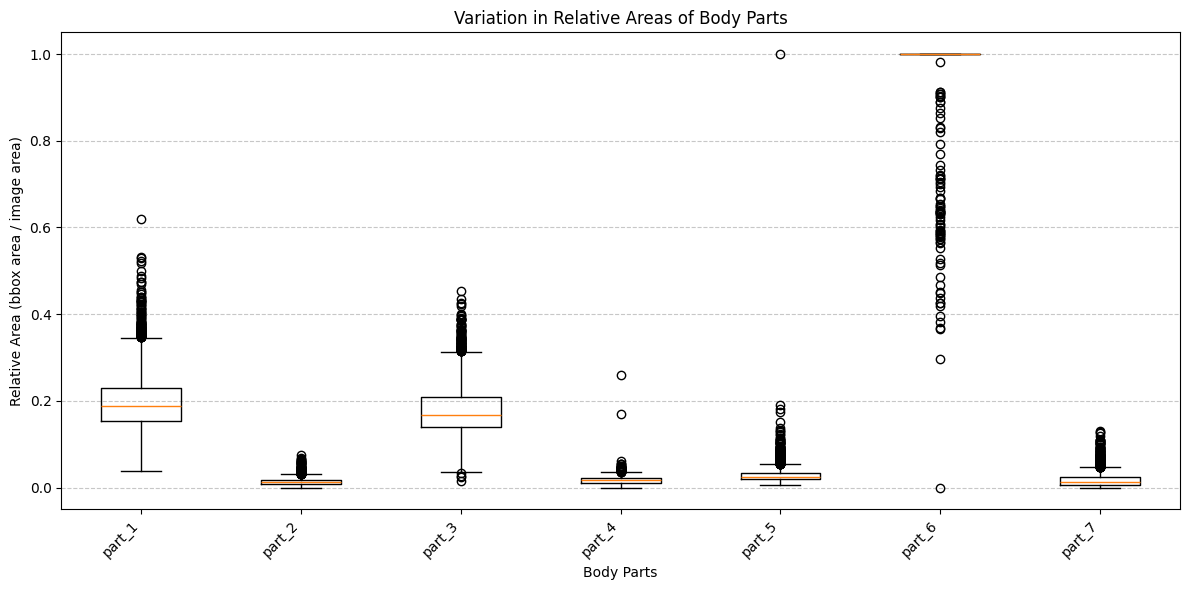

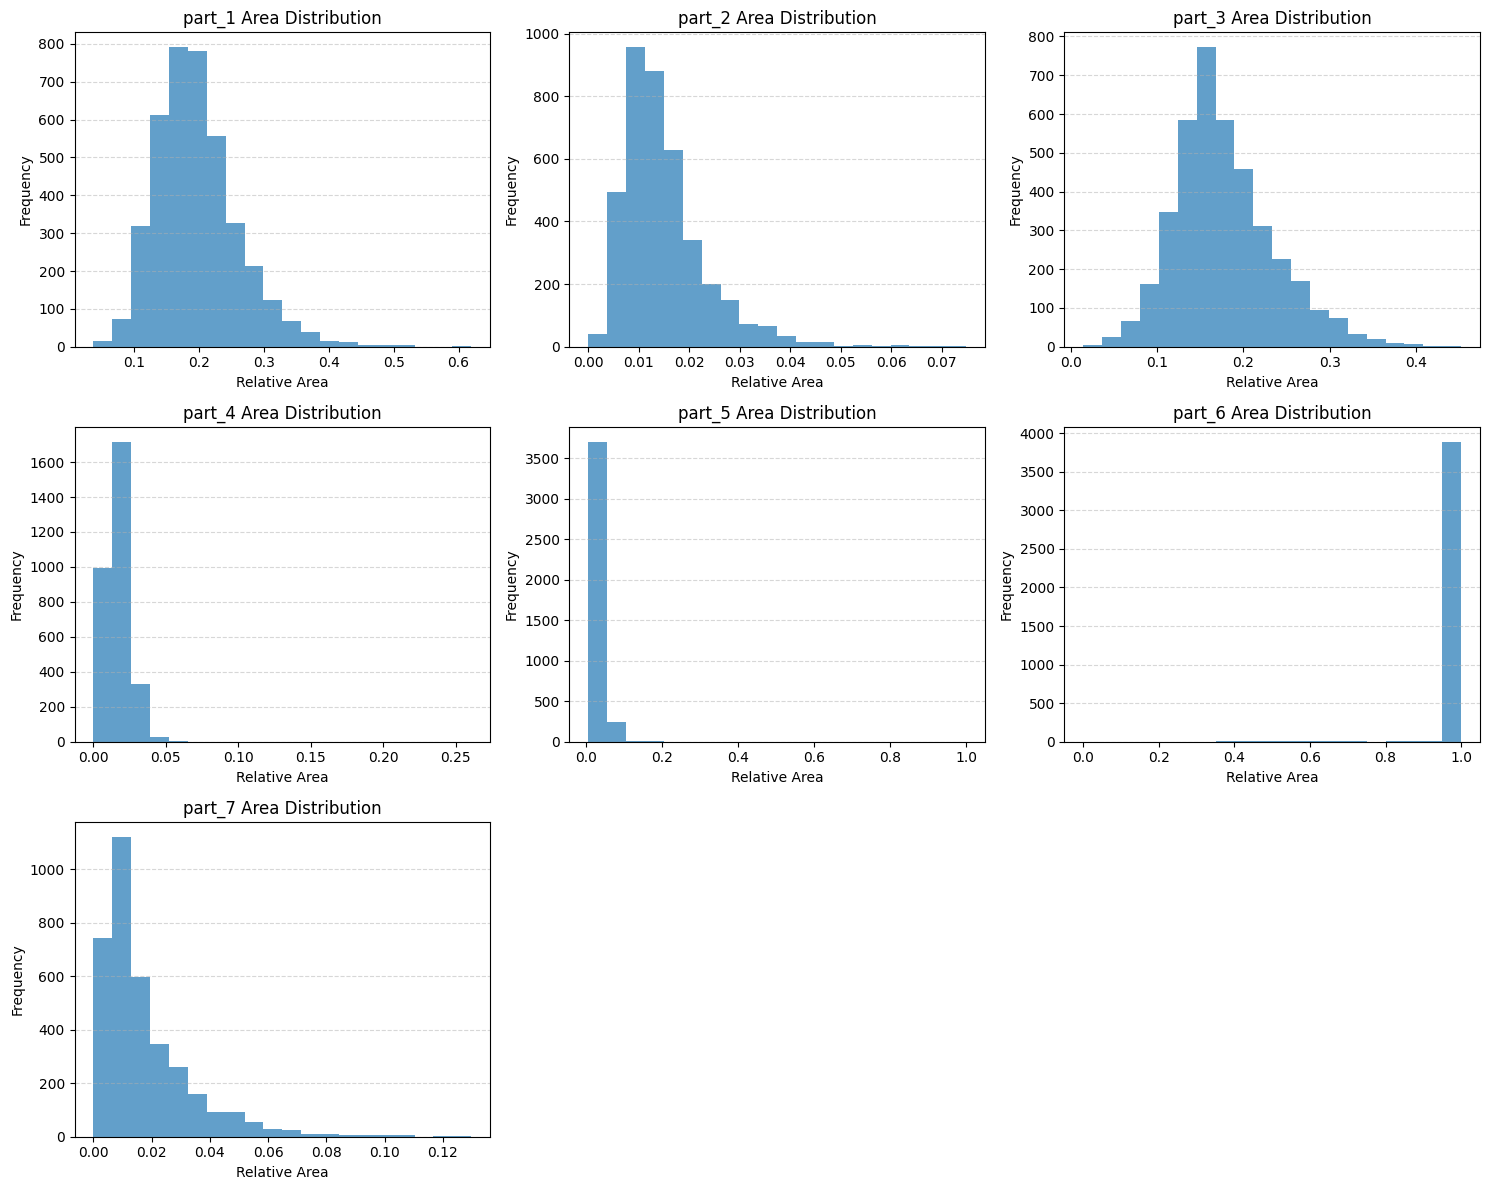

/tmp/ipykernel_1048701/3946592361.py:497: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(aspect_ratios_data, labels=parts)


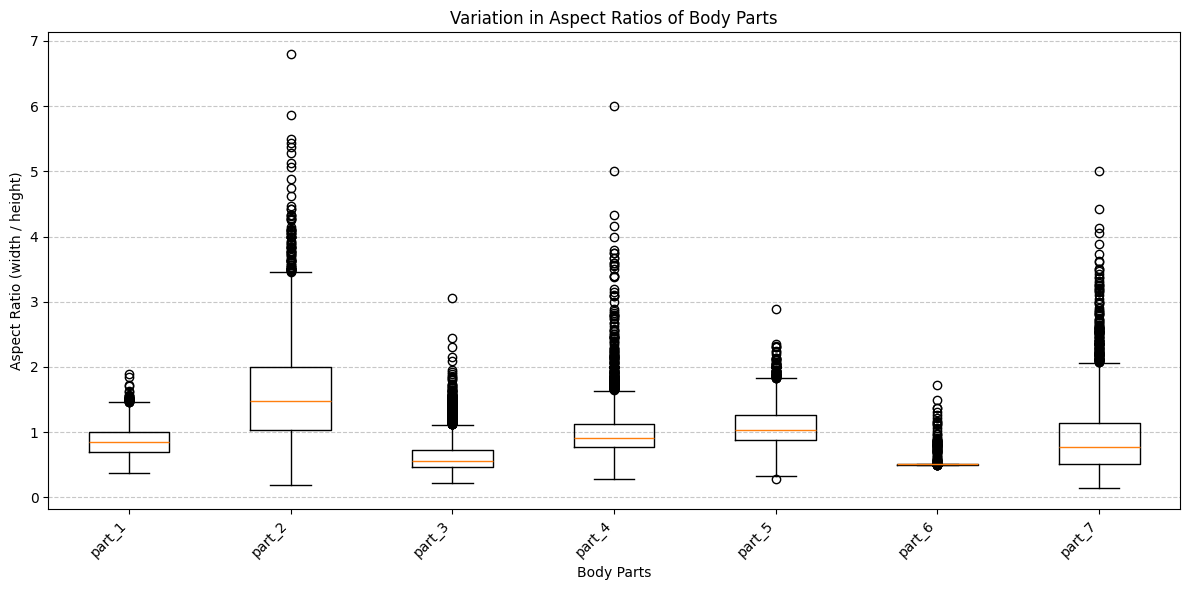

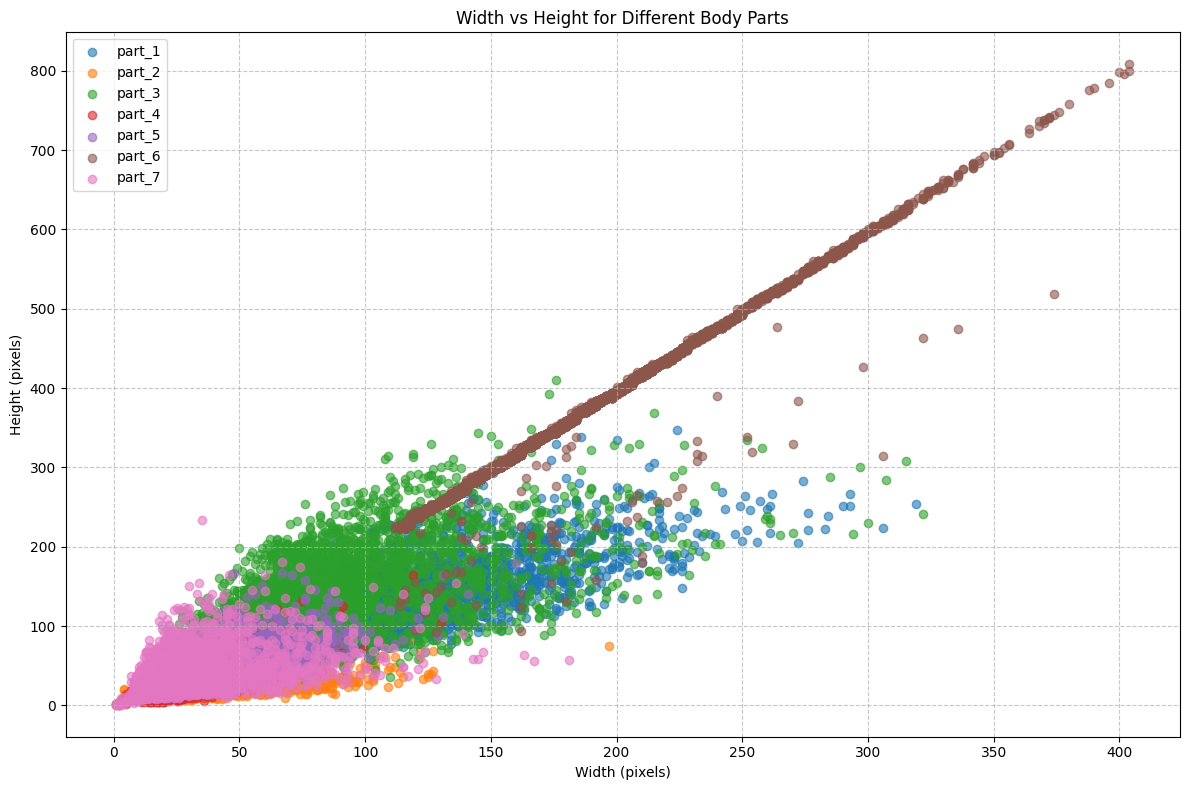

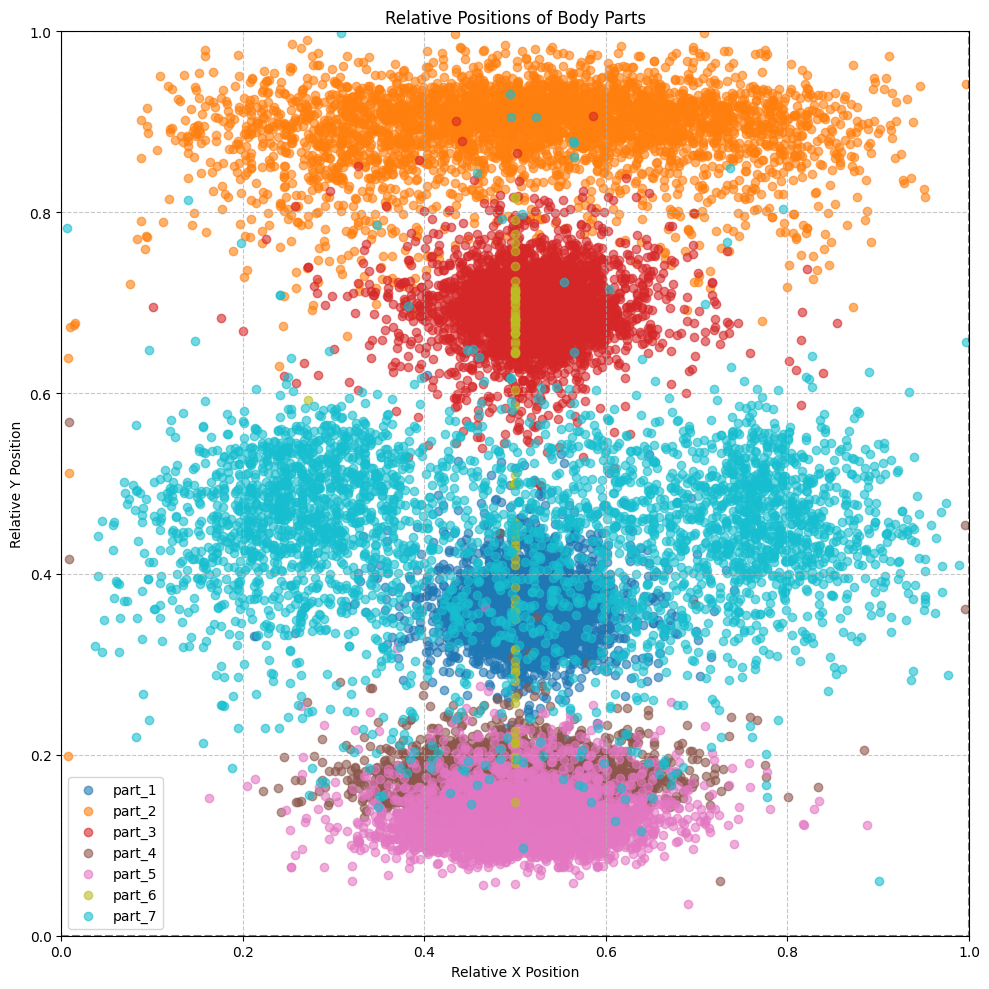

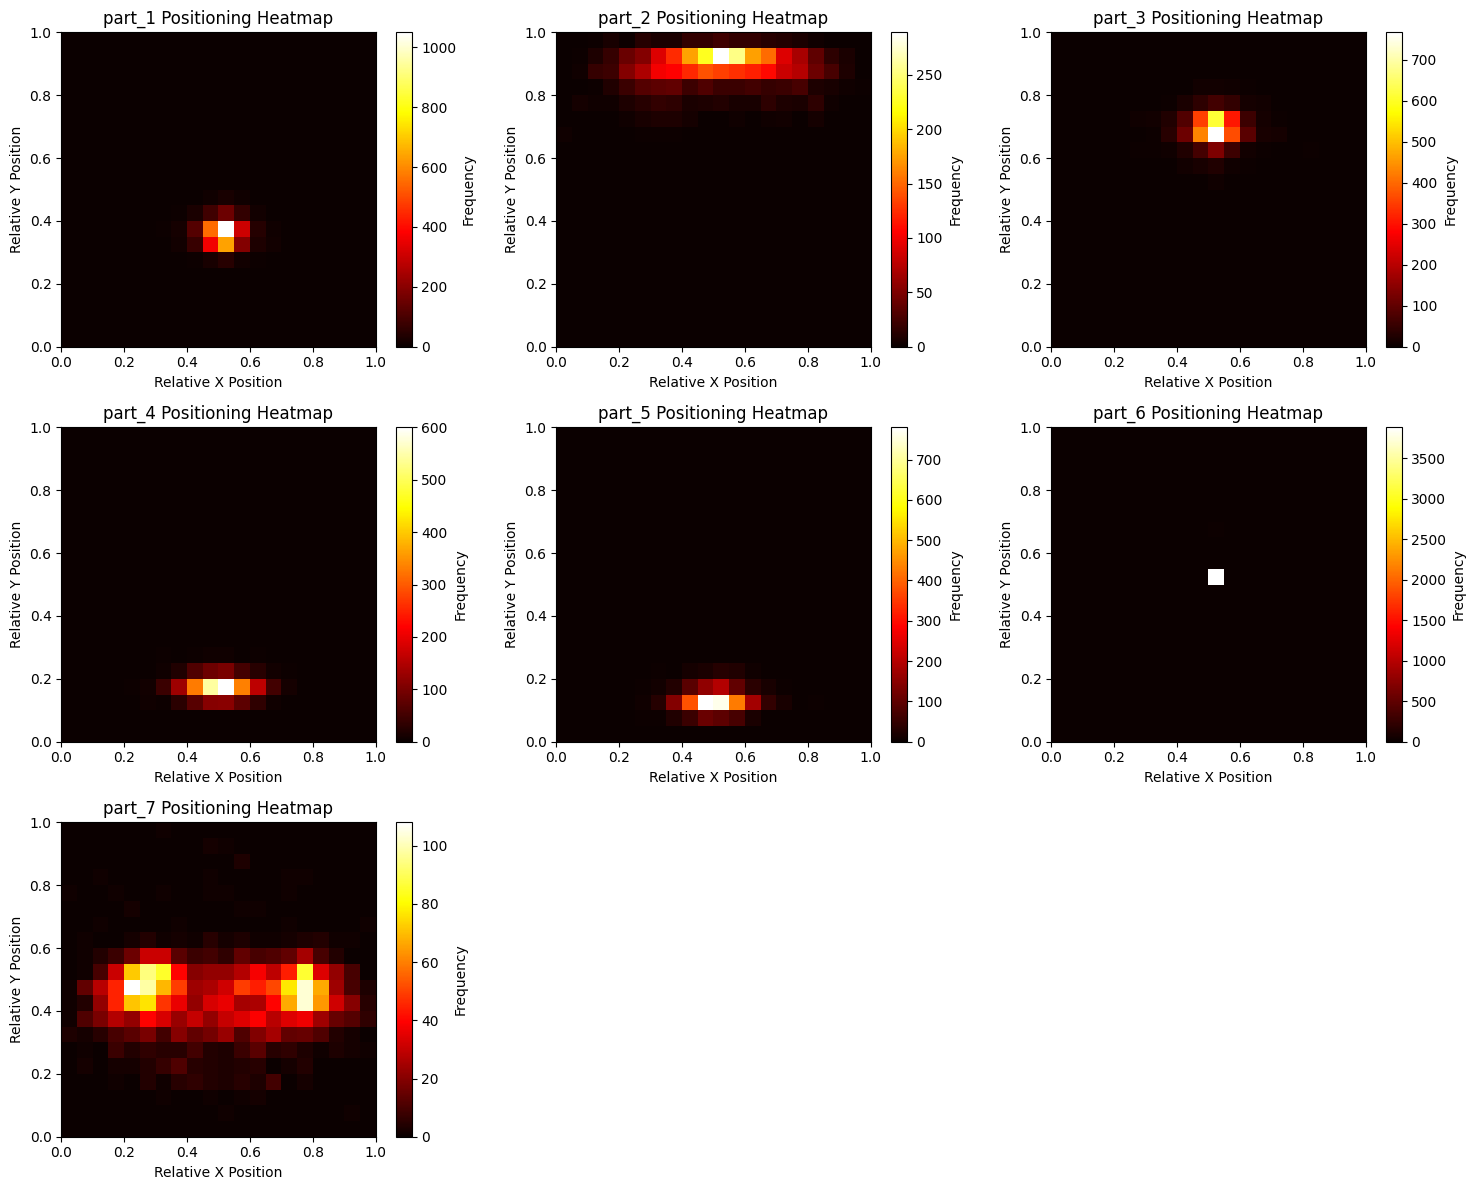


Exporting analysis report...
Analysis report exported to analysis_report

Processing complete!


In [2]:

# 9. Analyze and visualize variations in scale, aspect ratio, and positioning
print("\nAnalyzing variations in scale, aspect ratio, and positioning...")
stats = processor.analyze_and_visualize_variations()

# 10. Export detailed analysis report
print("\nExporting analysis report...")
processor.export_analysis_report(stats, analysis_dir)

print("\nProcessing complete!")

### 4.3

/home/omen/miniconda3/envs/instantmesh/lib/python3.10/site-packages/torchvision/models/_utils.py:135: UserWarning: Using 'backbone_name' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(
/home/omen/miniconda3/envs/instantmesh/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/omen/miniconda3/envs/instantmesh/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading saved model from ./Datasets/q3.pth


wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: karkepavan230 (karkepavan230-iiit-hyderabad) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 1/5, Loss: 0.1968, Time: 192.45s
Epoch 2/5, Loss: 0.1957, Time: 196.80s
Epoch 3/5, Loss: 0.1926, Time: 194.51s
Epoch 4/5, Loss: 0.1883, Time: 194.20s
Epoch 5/5, Loss: 0.1833, Time: 193.66s


epoch,▁▃▅▆█
epoch_time,▁█▄▄▃
loss,█▇▆▄▁
epoch,5
epoch_time,193.66449
loss,0.18327


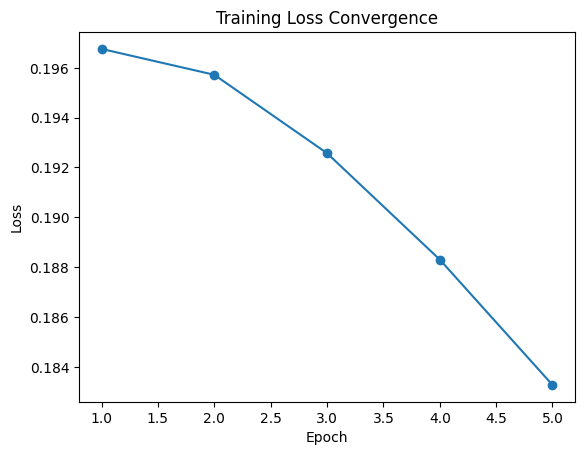

mAP at IoU 0.5: 0.748
mAP at IoU 0.75: 0.496
mAP at IoU 0.9: 0.236
part_1 Precision: 0.861
part_2 Precision: 0.208
part_3 Precision: 0.760
part_4 Precision: 0.604
part_5 Precision: 0.634
part_6 Precision: 0.662
part_7 Precision: 0.190


In [3]:
import torch
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Dataset
from torchvision.models.detection import FasterRCNN
from torchvision.models import resnet18
from torchvision.models.detection.backbone_utils import resnet_fpn_backbone
import cv2
import numpy as np
import json
import os
import time
import matplotlib.pyplot as plt
from collections import defaultdict
from torchvision.ops import box_iou

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

class HumanPartsDataset(Dataset):
    def __init__(self, annotations, transforms=None):
        self.annotations = annotations
        self.transforms = transforms
    
    def __getitem__(self, idx):
        ann = self.annotations[idx]
        img = cv2.imread(ann['file_path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = torch.tensor(img).permute(2, 0, 1).float() / 255.0
        
        bboxes = torch.tensor([bbox for bbox in ann['bboxes'].values()], dtype=torch.float32)
        labels = torch.tensor(range(1, len(bboxes) + 1), dtype=torch.int64)
        
        target = {'boxes': bboxes, 'labels': labels}
        
        if self.transforms:
            img = self.transforms(img)
        
        return img, target
    
    def __len__(self):
        return len(self.annotations)

with open("annotations/train_annotations.json", "r") as f:
    train_anns = json.load(f)
with open("annotations/val_annotations.json", "r") as f:
    val_anns = json.load(f)

train_transforms = T.Compose([
    T.RandomHorizontalFlip(0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
])

train_dataset = HumanPartsDataset(train_anns, transforms=train_transforms)
val_dataset = HumanPartsDataset(val_anns)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, pin_memory=True, num_workers=4, collate_fn=lambda x: tuple(zip(*x)))
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, pin_memory=True, num_workers=4, collate_fn=lambda x: tuple(zip(*x)))

backbone = resnet_fpn_backbone('resnet18', pretrained=True)
model = FasterRCNN(backbone, num_classes=len(train_anns[0]['bboxes']) + 1)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

losses = []

# Load model if it exists
MODEL_PATH = './Datasets/q3.pth'
if os.path.exists(MODEL_PATH):
    print("Loading saved model from", MODEL_PATH)
    model.load_state_dict(torch.load(MODEL_PATH))
    model.to(device)
else:
    print("No saved model found. Starting from scratch.")

import wandb


def train_model(model, train_loader, epochs=5 ):
    model.train()
    wandb.init(project="Q3_lastCV3")
    for epoch in range(epochs):
        start_time = time.time()
        running_loss = 0
        for imgs, targets in train_loader:
            imgs = [img.to(device) for img in imgs]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            optimizer.zero_grad()
            loss_dict = model(imgs, targets)
            loss = sum(loss for loss in loss_dict.values())
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        epoch_time = time.time() - start_time
        epoch_loss = running_loss / len(train_loader)
        losses.append(epoch_loss)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Time: {epoch_time:.2f}s")
        # Log metrics to wandb
        wandb.log({
            "epoch": epoch + 1,
            "loss": epoch_loss,
            "epoch_time": epoch_time,
        })
        torch.save(model.state_dict(), MODEL_PATH)

    wandb.finish()
train_model(model, train_loader)

plt.plot(range(1, len(losses) + 1), losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Convergence')
plt.show()



def compute_mAP(model, val_loader, iou_thresholds=[0.5, 0.75, 0.9]):
    model.eval()
    avg_precisions = {iou: [] for iou in iou_thresholds}
    
    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs = [img.to(device) for img in imgs]
            preds = model(imgs)
            
            for pred, target in zip(preds, targets):
                for iou_thr in iou_thresholds:
                    iou = box_iou(pred['boxes'].to(device), target['boxes'].to(device))
                    tp = (iou > iou_thr).sum().item()
                    fp = len(pred['boxes']) - tp
                    fn = len(target['boxes']) - tp

                    # print(pred['labels'],target['labels']) tensor([1, 6, 4, 5, 3, 6, 2, 7], device='cuda:1') tensor([1, 2, 3, 4, 5, 6, 7])

                    precision = tp / (tp + fp) if tp + fp > 0 else 0
                    avg_precisions[iou_thr].append(precision)
    
    for iou_thr in iou_thresholds:
        print(f"mAP at IoU {iou_thr}: {np.mean(avg_precisions[iou_thr]):.3f}")

compute_mAP(model, val_loader)

part_names = list(train_anns[0]['bboxes'].keys())
def evaluate_per_part(model, val_loader, part_names):
    model.eval()
    part_precisions = defaultdict(list)
    
    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs = [img.to(device) for img in imgs]
            preds = model(imgs)
            
            for pred, target in zip(preds, targets):
                for part_idx, part_name in enumerate(part_names, start=1):
                    part_mask = target['labels'] == part_idx
                    part_pred_mask = pred['labels'] == part_idx
                    
                    iou = box_iou(pred['boxes'][part_pred_mask].to(device), target['boxes'][part_mask].to(device))
                    tp = (iou > 0.5).sum().item()
                    precision = tp / (tp + (part_pred_mask.sum().item() - tp)) if tp + (part_pred_mask.sum().item() - tp) > 0 else 0
                    part_precisions[part_name].append(precision)
    
    for part_name, precisions in part_precisions.items():
        print(f"{part_name} Precision: {np.mean(precisions):.3f}")

evaluate_per_part(model, val_loader, part_names)

### it would have been nice if legs have 2 different colour
### it is able to detect face , leg of other person not in GT, so its nice thing model is learning something
### model has learned to diffeentiate parts well, with more taraining it can be improved further to reduce overlapping boxes and increase precision
### model focuses on person's part located in middle of image
### maybe it could be checking to give boxes per part oly if full person is recognized

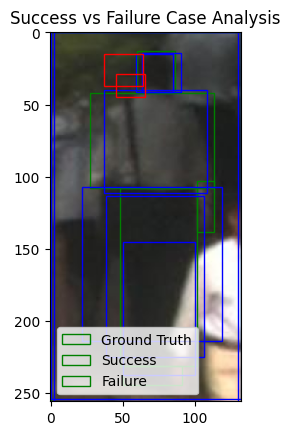

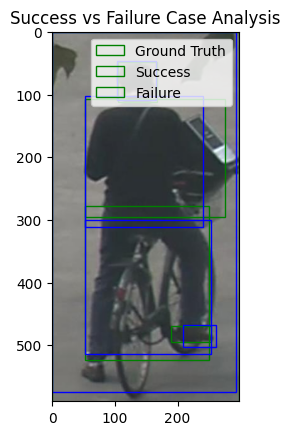

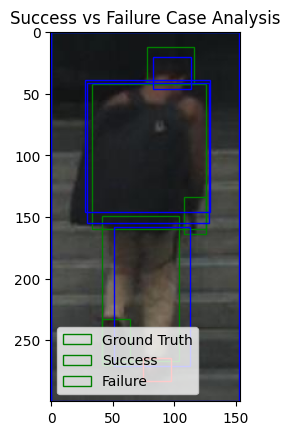

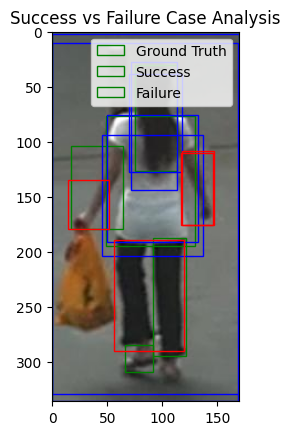

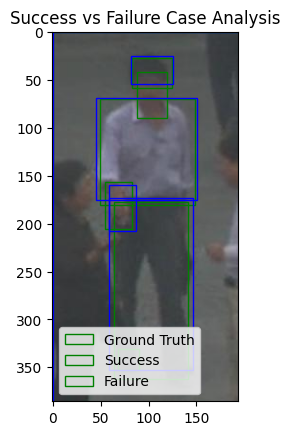

In [7]:
def visualize_success_failure_cases(model, dataset, sample_count=5, iou_threshold=0.5):
    model.eval()
    samples = np.random.choice(len(dataset), sample_count, replace=False)

    for idx in samples:
        img, target = dataset[idx]
        img = img.unsqueeze(0).to(device)
        
        with torch.no_grad():
            pred = model(img)[0]

        img = img.squeeze(0).permute(1, 2, 0).cpu().numpy()
        plt.imshow(img)
        
        gt_boxes = target['boxes'].cpu().numpy()
        pred_boxes = pred['boxes'].cpu().numpy()

        if len(pred_boxes) > 0 and len(gt_boxes) > 0:
            iou = box_iou(torch.tensor(pred_boxes), torch.tensor(gt_boxes)).cpu().numpy()
            success_idx = np.where(iou.max(axis=1) > iou_threshold)[0]  # High IoU -> Success
            failure_idx = np.where(iou.max(axis=1) <= iou_threshold)[0]  # Low IoU -> Failure
        else:
            success_idx, failure_idx = [], range(len(pred_boxes))  # All failures if no GT match
        
        # Plot Ground Truth (Green)
        for bbox in gt_boxes:
            x1, y1, x2, y2 = bbox.astype(int)
            plt.gca().add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, edgecolor='g', facecolor='none', label="GT"))

        # Plot Successful Detections (Blue)
        for idx in success_idx:
            x1, y1, x2, y2 = pred_boxes[idx].astype(int)
            plt.gca().add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, edgecolor='b', facecolor='none', label="Success"))

        # Plot Failure Cases (Red)
        for idx in failure_idx:
            x1, y1, x2, y2 = pred_boxes[idx].astype(int)
            plt.gca().add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, edgecolor='r', facecolor='none', label="Failure"))

        plt.legend(["Ground Truth", "Success", "Failure"])
        plt.title("Success vs Failure Case Analysis")
        plt.show()

# Run the visualization
visualize_success_failure_cases(model, val_dataset)


In [5]:

# Analysis and Discussion


def compute_mAP(model, val_loader, iou_thresholds=[0.5, 0.75, 0.9]):
    model.eval()
    avg_precisions = {iou: [] for iou in iou_thresholds}
    
    # To store precision, recall, and failure cases
    performance_stats = {
        "precision": [],
        "recall": [],
        "failures": 0
    }
    
    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs = [img.to(device) for img in imgs]
            preds = model(imgs)
            
            for pred, target in zip(preds, targets):
                for iou_thr in iou_thresholds:
                    iou = box_iou(pred['boxes'].to(device), target['boxes'].to(device))
                    tp = (iou > iou_thr).sum().item()
                    fp = len(pred['boxes']) - tp
                    fn = len(target['boxes']) - tp

                    precision = tp / (tp + fp) if tp + fp > 0 else 0
                    recall = tp / (tp + fn) if tp + fn > 0 else 0
                    
                    # Update performance stats
                    performance_stats["precision"].append(precision)
                    performance_stats["recall"].append(recall)
                    
                    # Failure cases (you can customize this based on your definition of failure)
                    if fp > 0 or fn > 0:
                        performance_stats["failures"] += 1
                    
                    avg_precisions[iou_thr].append(precision)
    
    # Print mAP values
    for iou_thr in iou_thresholds:
        print(f"mAP at IoU {iou_thr}: {np.mean(avg_precisions[iou_thr]):.3f}")
    
    # Return the performance stats for further analysis
    return performance_stats 

def analyze_performance(stats):
    print("=== Model Performance Analysis ===")
    
    # Extract overall precision, recall, and failure cases from the stats
    avg_precision = np.mean(stats["precision"]) if stats["precision"] else 0
    avg_recall = np.mean(stats["recall"]) if stats["recall"] else 0
    failures = stats["failures"]

    # Print out the statistics
    print(f"\nAverage Precision: {avg_precision:.3f}")
    print(f"Average Recall: {avg_recall:.3f}")
    print(f"Failure Cases: {failures}")

# Run the analysis
performance_stats = compute_mAP(model, val_loader)
analyze_performance(performance_stats)

def suggest_improvements():
    print("\n=== Suggested Improvements ===")
    print("1. Use Transformer-based DETR for better occlusion handling.")
    print("2. Multi-scale feature extraction to detect small parts.")
    print("3. Part-relationship modeling to improve contextual understanding.")
    print("4. Augment dataset with diverse viewpoints and occlusions.")


suggest_improvements()


mAP at IoU 0.5: 0.748
mAP at IoU 0.75: 0.496
mAP at IoU 0.9: 0.236
=== Model Performance Analysis ===

Average Precision: 0.493
Average Recall: 0.598
Failure Cases: 2302

=== Suggested Improvements ===
1. Use Transformer-based DETR for better occlusion handling.
2. Multi-scale feature extraction to detect small parts.
3. Part-relationship modeling to improve contextual understanding.
4. Augment dataset with diverse viewpoints and occlusions.


idx  392


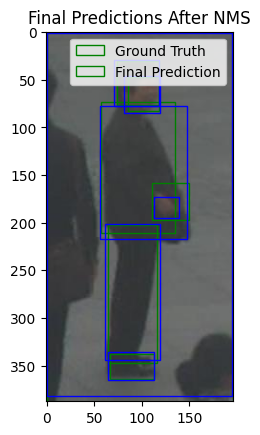

idx  41


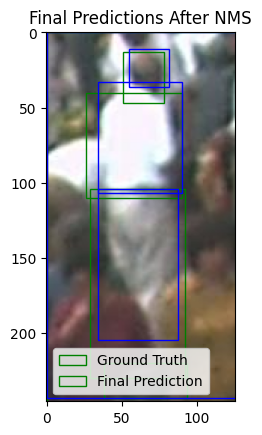

idx  315


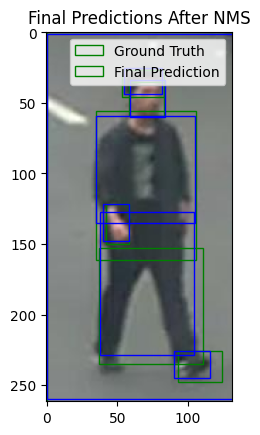

idx  357


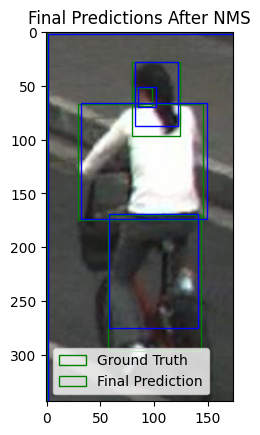

idx  592


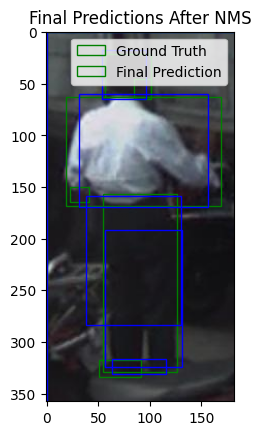

In [14]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from torchvision.ops import nms

def visualize_final_predictions(model, dataset, sample_count=5, iou_threshold=0.7, score_threshold=0.5):
    """
    Visualizes final predictions after applying Non-Maximum Suppression (NMS)
    
    Args:
        model: Trained Faster R-CNN model
        dataset: Validation dataset
        sample_count: Number of samples to visualize
        iou_threshold: IoU threshold for NMS
        score_threshold: Confidence score threshold
    """
    model.eval()
    samples = np.random.choice(len(dataset), sample_count, replace=False)

    for idx in samples:
        print("idx ",idx)
        img, target = dataset[idx]
        img = img.unsqueeze(0).to(device)
        
        with torch.no_grad():
            pred = model(img)[0]

        img = img.squeeze(0).permute(1, 2, 0).cpu().numpy()
        plt.imshow(img)

        pred_boxes = pred['boxes'].cpu()
        pred_scores = pred['scores'].cpu()
        pred_labels = pred['labels'].cpu()

        # Apply NMS
        keep = nms(pred_boxes, pred_scores, iou_threshold)
        pred_boxes = pred_boxes[keep]
        pred_scores = pred_scores[keep]
        pred_labels = pred_labels[keep]

        # Filter predictions by score threshold
        valid_idx = pred_scores > score_threshold
        pred_boxes = pred_boxes[valid_idx]
        pred_scores = pred_scores[valid_idx]
        pred_labels = pred_labels[valid_idx]

        # Plot Ground Truth (Green)
        for bbox in target['boxes'].cpu().numpy():
            x1, y1, x2, y2 = bbox.astype(int)
            plt.gca().add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, edgecolor='g', facecolor='none', label="GT"))

        # Plot Final Predictions (Blue)
        for bbox in pred_boxes.numpy():
            x1, y1, x2, y2 = bbox.astype(int)
            plt.gca().add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, edgecolor='b', facecolor='none', label="Prediction"))

        plt.legend(["Ground Truth", "Final Prediction"])
        plt.title("Final Predictions After NMS")
        plt.show()

# Run visualization
visualize_final_predictions(model, val_dataset)


## [Statistics of compute and loss](<Last question CV_Q3.pdf>)